<a href="https://colab.research.google.com/github/liwiaflorkiwicz/EEG_dimensiality_reduction/blob/main/LDAvsUMAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import time
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv('/content/dataset_A_hands.csv', header=0)
X = data.drop(columns=['Label'])
y = data['Label']

le = LabelEncoder()
y_num = le.fit_transform(y)

results = []

lda_configs = [
    {'solver': 'svd', 'shrinkage': None, 'name': 'LDA (SVD, No shrink)'},
    {'solver': 'eigen', 'shrinkage': 0.0, 'name': 'LDA (Eigen, Shrink=0.0)'},
    {'solver': 'eigen', 'shrinkage': 0.5, 'name': 'LDA (Eigen, Shrink=0.5)'}
]

umap_configs = [
    {'n_neighbors': 15, 'min_dist': 0.1, 'name': 'UMAP Sup. (Default: 15, 0.1)'},
    {'n_neighbors': 5, 'min_dist': 0.1, 'name': 'UMAP Sup. (Lokalny: 5, 0.1)'},
    {'n_neighbors': 5, 'min_dist': 0.5, 'name': 'UMAP Sup. (Lokalny: 5, 0.5)'}
]

In [14]:
for config in lda_configs:
    start_time = time.time()

    lda = LinearDiscriminantAnalysis(solver=config['solver'], shrinkage=config['shrinkage'])
    X_emb = lda.fit_transform(X, y_num)

    exec_time = time.time() - start_time

    # Metryki
    trust = trustworthiness(X, X_emb, n_neighbors=5)
    sil = silhouette_score(X_emb, y_num)

    f_stat, p_val = f_classif(X_emb, y_num)
    f_stat_mean = f_stat.mean()

    results.append({
        'Model / Konfiguracja': config['name'],
        'Trustworthiness': np.round(trust, 4),
        'Silhouette Score': np.round(sil, 4),
        'F-Statistic (Średnia)': np.round(f_stat_mean, 2),
        'Czas Wykonania [s]': np.round(exec_time, 4)
    })

In [15]:
for config in umap_configs:
    start_time = time.time()

    reducer = umap.UMAP(n_neighbors=config['n_neighbors'], min_dist=config['min_dist'], random_state=42)
    X_emb = reducer.fit_transform(X, y=y_num)

    exec_time = time.time() - start_time

    # Metryki
    trust = trustworthiness(X, X_emb, n_neighbors=5)
    sil = silhouette_score(X_emb, y_num)

    # Statystyka F
    f_stat, p_val = f_classif(X_emb, y_num)
    f_stat_mean = f_stat.mean()

    results.append({
        'Model / Konfiguracja': config['name'],
        'Trustworthiness': np.round(trust, 4),
        'Silhouette Score': np.round(sil, 4),
        'F-Statistic (Średnia)': np.round(f_stat_mean, 2),
        'Czas Wykonania [s]': np.round(exec_time, 4)
    })

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


           Model / Konfiguracja  Trustworthiness  Silhouette Score  \
0          LDA (SVD, No shrink)           0.5226            0.0494   
1       LDA (Eigen, Shrink=0.0)           0.5226            0.0494   
2       LDA (Eigen, Shrink=0.5)           0.5459            0.0031   
3  UMAP Sup. (Default: 15, 0.1)           0.9639            0.0199   
4   UMAP Sup. (Lokalny: 5, 0.1)           0.9622           -0.0204   
5   UMAP Sup. (Lokalny: 5, 0.5)           0.9588           -0.0456   

   F-Statistic (Średnia)  Czas Wykonania [s]  
0                  53.80              0.0119  
1                  53.80              0.0388  
2                  30.24              0.0426  
3                   6.65              0.6918  
4                   4.23              0.5091  
5                   2.23              0.5125  


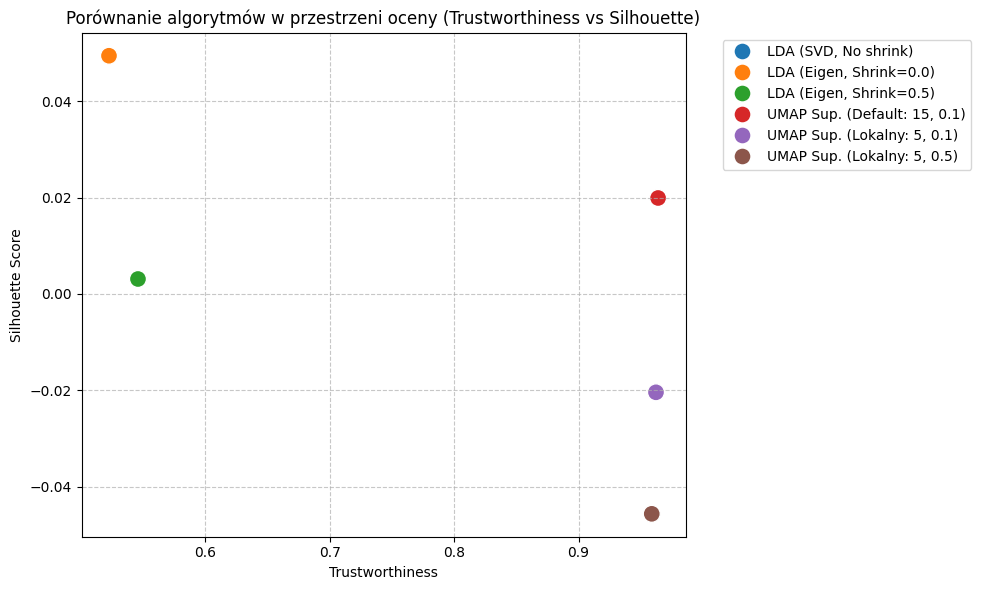

In [17]:
df_results = pd.DataFrame(results)

print(df_results)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_results, x='Trustworthiness', y='Silhouette Score',
                hue='Model / Konfiguracja', s=150, palette='tab10')
plt.title("Porównanie algorytmów w przestrzeni oceny (Trustworthiness vs Silhouette)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()